### 중요함!! 인공지능 모델 만들 때 가장 많이 쓰이는 필수 기술
# 전이학습(Transfer Learning)
# 데이터 증강(Data Augmentation)

# CNN전이학습 / data augmentation
* 전이학습 : 사전에 훈련된 모델을 가져와서 내 목표에 맞게 조금 고쳐서 사용하는 것
* data_agmentation(데이터 증강) : 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈, 기존 이미지데이터에 변형을 가해서 **데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)**

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [1]:
from keras.preprocessing.image import img_to_array, array_to_img, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
image = load_img("./data/catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

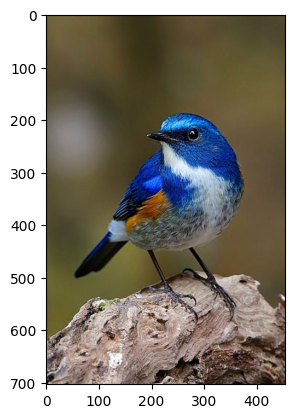

In [6]:
plt.imshow(image)
plt.show()

이미지 증폭

In [7]:
imggen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

이미지 차원 늘리기

In [8]:
image_array.shape

(703, 454, 3)

In [9]:
(1, ) + image_array.shape

(1, 703, 454, 3)

In [10]:
image_array.reshape((1,) + image_array.shape).shape

(1, 703, 454, 3)

In [11]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

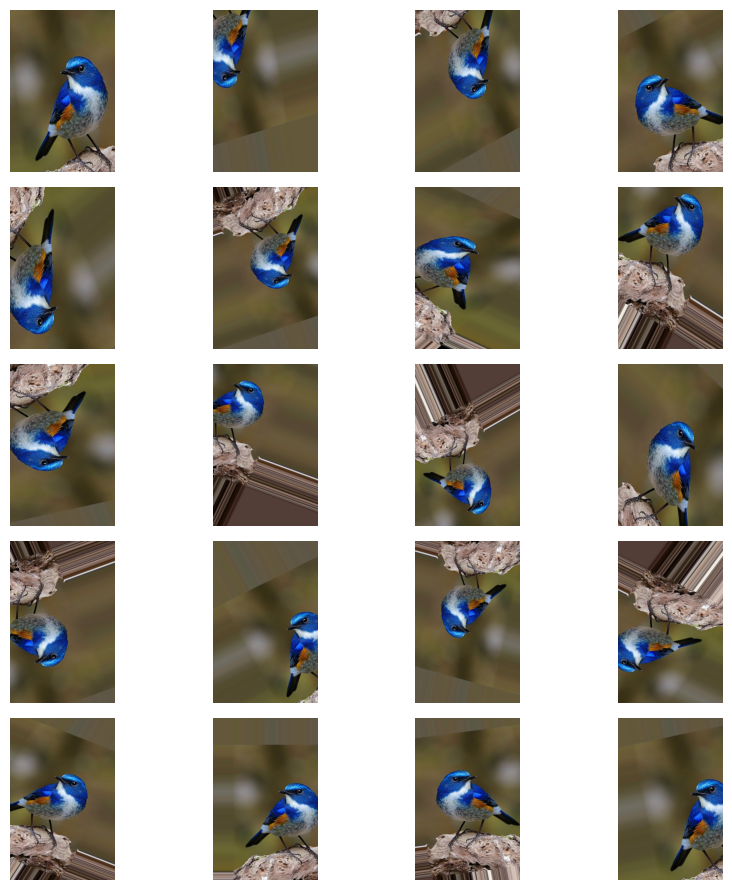

In [12]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류 모델 만들기

In [25]:
# 데이터 로드
train_dir = "./data/catanddog/train/"
valid_dir = "./data/catanddog/validation/"
batch_size = 16 # 한 번에 불러오는 사진의 개수 16 - 32 개 사이로 지정
image_size = (224, 224)  # 모델의 입력 크기에 맞춤

In [26]:
# 이미지 증강 훈련데이터에만 적용
train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.2,
        shear_range=0.6,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
        )

valid_aug = ImageDataGenerator(rescale=1./255)

# 모든 데이터에 이미지 증강
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)


Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [27]:
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [28]:
model = Sequential()
model.add(Input(shape=X_batch.shape[1:]))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 220, 220, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 220, 220, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 108, 108, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 108, 108, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 106, 106, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 106, 106, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 51, 51, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 51, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 49, 49, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 49, 49, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,462,626 (9.39 MB)

 Trainable params: 2,461,858 (9.39 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6519 - loss: 0.6285 - val_accuracy: 0.7347 - val_loss: 0.6232
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6727 - loss: 0.6067 - val_accuracy: 0.6224 - val_loss: 0.8426
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6597 - loss: 0.6020 - val_accuracy: 0.7347 - val_loss: 0.5739
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6571 - loss: 0.6077 - val_accuracy: 0.7041 - val_loss: 0.6515
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6805 - loss: 0.5972 - val_accuracy: 0.6224 - val_loss: 0.8272
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6675 - loss: 0.5762 - val_accuracy: 0.5000 - val_loss: 2.2123
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7221 - loss: 0.5442 - val_accuracy: 0.5000 - val_loss: 1.4363
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6675 - loss: 0.5970 - val_accuracy: 0.5408 - val_loss:

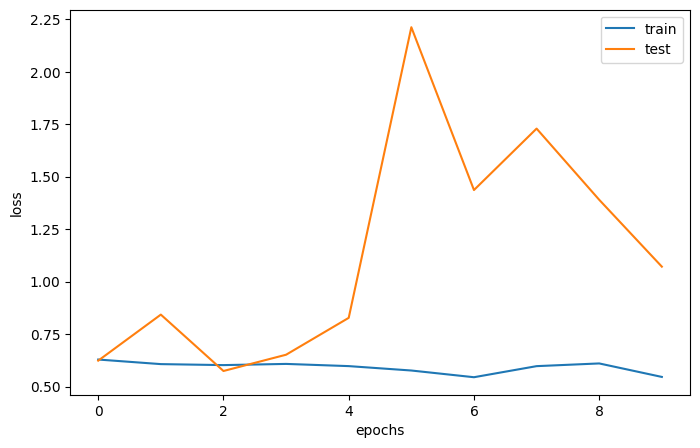

In [30]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
model_path = "./model/catndog_cnn_model.keras"
model_save = ModelCheckpoint(filepath=model_path, save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
history = model.fit(train_gen, epochs=10, validation_data=valid_gen,
                   callbacks=[model_save, early_stop]) # epochs 변경시킴 원래는 1000임
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [31]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


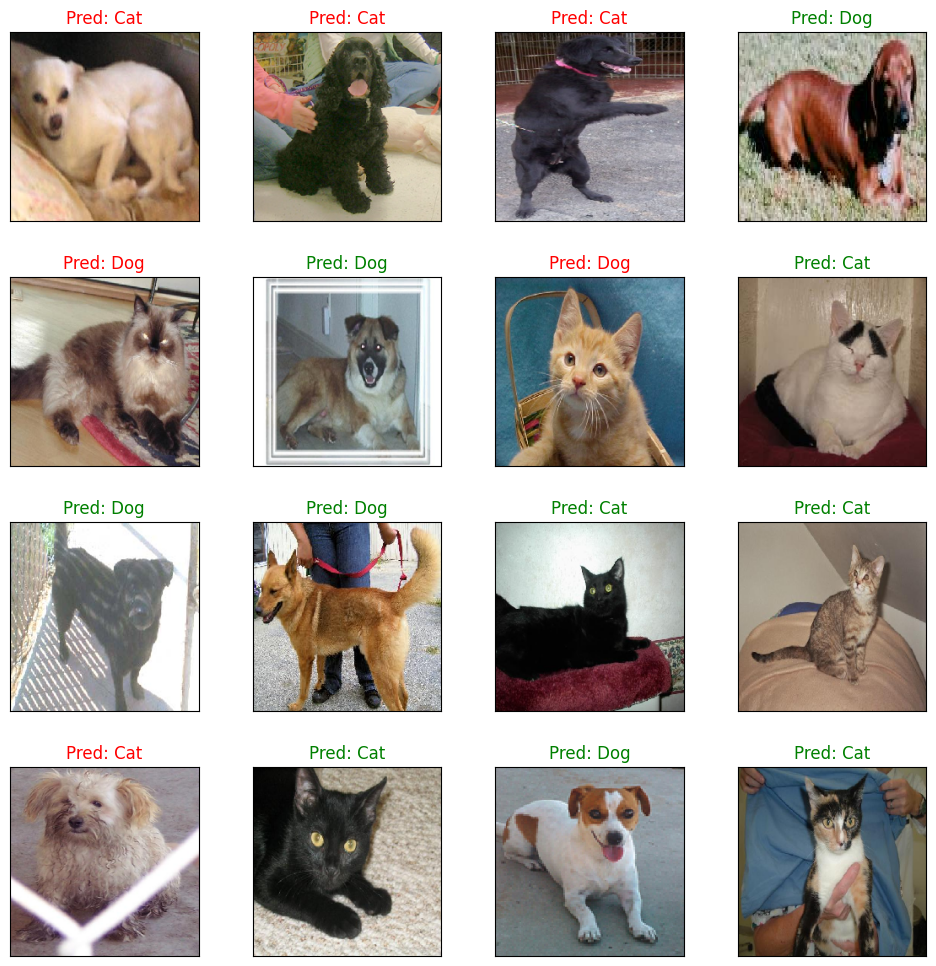


cnn_best_model평가 결과: Loss: 0.6835, Accuracy: 0.6250


In [33]:
# best 모델 로드
cnn_best_model = load_model("./model/catndog_cnn_model.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* Keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [34]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input
import tensorflow as tf

In [35]:
# ✅ ResNet50에 맞는 이미지 증강기 (rescale 제거 → preprocess_input 사용)
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✔️ ResNet 전용 전처리
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.6,
    zoom_range=0.3,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ✔️ Validation도 동일하게 처리
)

# ✅ 이미지 제너레이터 생성
train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=image_size,  # 예: (224, 224)
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_gen = valid_aug.flow_from_directory(
    valid_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ✅ 배치 확인
X_batch, y_batch = next(train_gen)
print(X_batch.shape)  # 예: (32, 224, 224, 3)
print(y_batch.shape)
print(train_gen.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [36]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [37]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 2)                   │           4,098 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4544 - loss: 0.9365
Epoch 1: val_loss improved from None to 0.67070, saving model to ./model/res50_catndog.keras

Epoch 1: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4753 - loss: 0.9163 - val_accuracy: 0.6939 - val_loss: 0.6707
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6132 - loss: 0.7115
Epoch 2: val_loss improved from 0.67070 to 0.53594, saving model to ./model/res50_catndog.keras

Epoch 2: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6494 - loss: 0.6744 - val_accuracy: 0.8061 - val_loss: 0.5359
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7644 - loss: 0.5283
Epoch 3: val_loss improved from 0.53594 to 0.39318, saving model to ./model/res50_catndog.keras

Epoch 3: finished saving model to ./model/res50_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accura

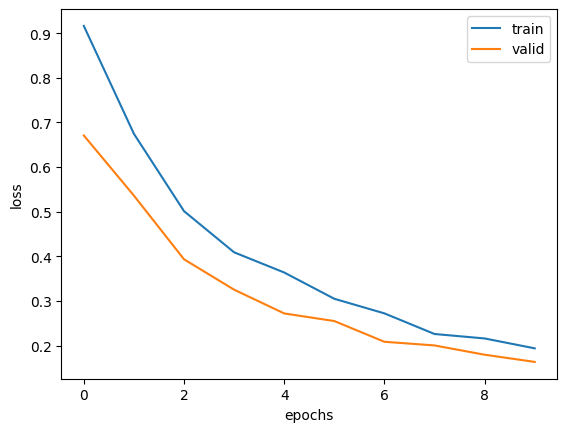

In [40]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=10, validation_data=valid_gen,
                           callbacks=[early_stop, check_point]) # epochs

plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step

[전체 Validation Accuracy] 0.5204
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


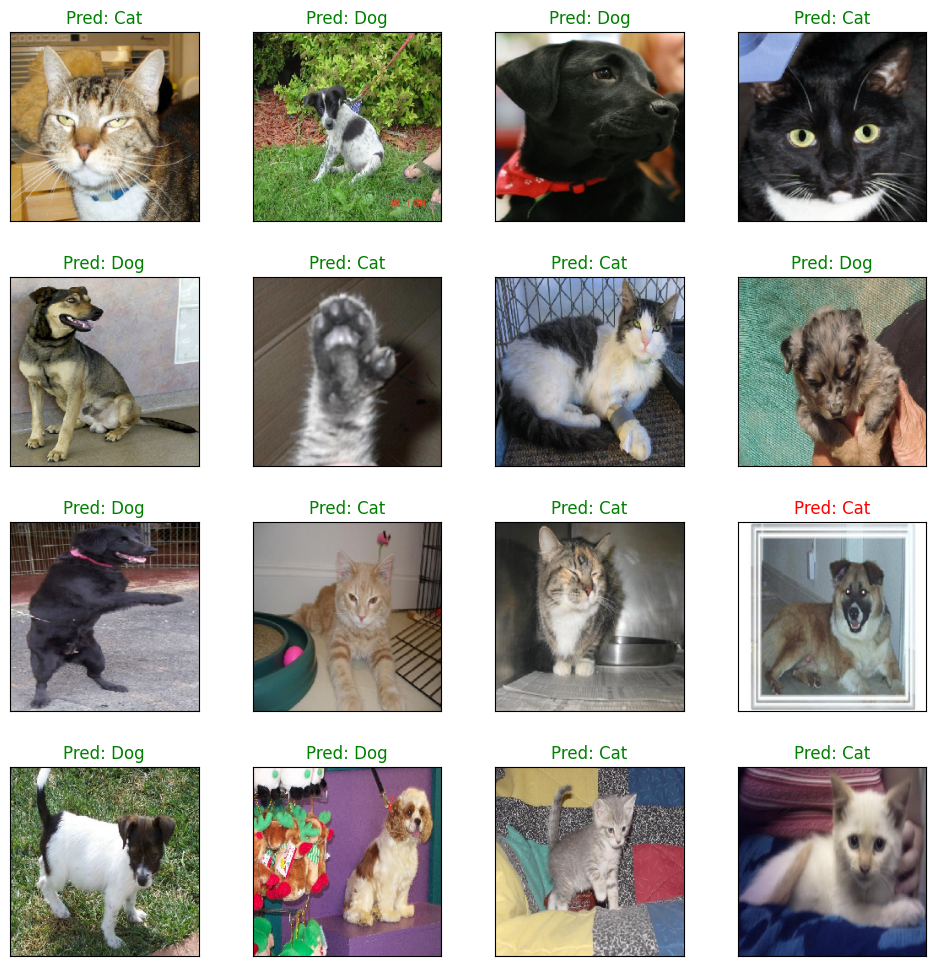

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9694 - loss: 0.1632

[모델 평가 결과] Loss: 0.1632, Accuracy: 0.9694


In [41]:
from sklearn.metrics import accuracy_score
# ✅ 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# ✅ 클래스 이름 추출
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ 전체 validation 데이터로 예측
cnn_pred = res50_best_model.predict(valid_gen, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen.classes  # 전체 정답

# ✅ 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ 시각화용: 소량 배치만 가져오기
sample_batch, label_batch = next(valid_gen)
sample_pred = res50_best_model.predict(sample_batch)
sample_pred_values = np.argmax(sample_pred, axis=1)
sample_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화: 이미지 복구 후 출력
def deprocess_input(x):
    """ResNet의 preprocess_input을 반대로 적용 (BGR→RGB + 평균값 복원)"""
    x = x.copy()
    # ImageNet 평균값 (BGR 순)
    mean = [103.939, 116.779, 123.68]
    x[..., 0] += mean[0]  # B
    x[..., 1] += mean[1]  # G
    x[..., 2] += mean[2]  # R
    x = x[..., ::-1]  # BGR → RGB
    return np.clip(x / 255.0, 0, 1)  # matplotlib은 0~1 사이값을 기대함

# ✅ 이미지 시각화
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, sample_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    img = deprocess_input(sample_batch[i])
    ax.imshow(img)
    pred_label = class_names[sample_pred_values[i]]
    true_label = class_names[sample_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ 전체 평가
loss, acc = res50_best_model.evaluate(valid_gen, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기
* convnextbase는 내부에 정규화 레이어가 있으므로 입력시 정규화 X
* 데이터 입력시 dtype은 float32 추천

In [42]:
from tensorflow.keras.applications import ConvNeXtBase

In [43]:
# 이미지 증강
train_aug2 = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest',
            dtype='float32')

valid_aug2 = ImageDataGenerator(dtype='float32')

# 이미지 제너레이터
train_gen2 = train_aug2.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen2 = valid_aug2.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch2, y_batch2 = next(train_gen2)
print(X_batch2.shape)
print(y_batch2.shape)
print(train_gen2.class_indices)

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [44]:
base_model3 = ConvNeXtBase(
    include_top=False,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)


350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [45]:
base_model3.trainable = False
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation="softmax"))

In [47]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/ConvNeXtBase_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history = ConvNeXtBase_model.fit(train_gen2, epochs=10, validation_data=valid_gen2,
                           callbacks=[early_stop, check_point]) # 원래 epochs=1000이었는데 변경
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6073 - loss: 0.7998 
Epoch 1: val_loss improved from None to 0.67547, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 1: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 382s 13s/step - accuracy: 0.6468 - loss: 0.7585 - val_accuracy: 0.6837 - val_loss: 0.6755
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7139 - loss: 0.5952
Epoch 2: val_loss improved from 0.67547 to 0.50948, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 2: finished saving model to ./model/ConvNeXtBase_catndog.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 242s 10s/step - accuracy: 0.7247 - loss: 0.5899 - val_accuracy: 0.8163 - val_loss: 0.5095
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8166 - loss: 0.3955
Epoch 3: val_loss improved from 0.50948 to 0.40648, saving model to ./model/ConvNeXtBase_catndog.keras

Epoch 3: finished saving model to ./model/ConvNeXtBase_catndog.keras

KeyboardInterrupt: 

In [48]:
# Best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출
class_indices = valid_gen2.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ [1] 전체 validation dataset으로 예측 및 정확도 계산
cnn_pred = ConvNeXtBase_best_model.predict(valid_gen2, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen2.classes  # 전체 validation 레이블

# 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ [2] 소량 배치만 시각화용으로 가져오기
small_batch, label_batch = next(valid_gen2)
small_pred = ConvNeXtBase_best_model.predict(small_batch)
small_pred_values = np.argmax(small_pred, axis=1)
small_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화 (최대 16장)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, small_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(small_batch[i].astype("uint8"))  # ConvNeXt는 0~255 이미지 입력
    pred_label = class_names[small_pred_values[i]]
    true_label = class_names[small_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ [3] 전체 validation 데이터로 loss, accuracy 평가
loss, acc = ConvNeXtBase_best_model.evaluate(valid_gen2, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")

1/7 ━━━━━━━━━━━━━━━━━━━━ 52s 9s/step

KeyboardInterrupt: 